In [14]:

import json
import os
import itertools 
from copy import deepcopy
import time

# Ordner erstellen (nachdem os importiert wurde)
os.makedirs("../results", exist_ok=True)

# --- Third-party libraries: numerical + plotting ---
import pandas as pd
import numpy as np                               # numerical computing (arrays, arange, hstack, etc.)
import matplotlib.pyplot as plt                  # plotting and visualization (figure, subplot, ax.plot, etc.)

# --- scikit-learn: models ---
from sklearn.tree import (
    DecisionTreeClassifier,                      # decision tree classifier
)

from sklearn.neighbors import (
    KNeighborsClassifier,                        # Nearest neighbors    
)

from sklearn.svm import (
    SVC,                                         # Support Vector Machines
)

from sklearn.linear_model import (
    LogisticRegression,                          # linear model: Logistic Regression
)

# --- Ensemble methods ---
from sklearn.ensemble import (
    VotingClassifier,                  # ensemble voting (hard / soft)
    BaggingClassifier,                 # bootstrap aggregating
    RandomForestClassifier,            # random forests
    ExtraTreesClassifier,              # extremely randomized trees
    StackingClassifier,                # stacking ensembles
    AdaBoostClassifier,                # adaptive boosting
    GradientBoostingClassifier,        # gradient boosting
    HistGradientBoostingClassifier,
)

# --- scikit-learn: model selection / evaluation ---
from sklearn.model_selection import (
    train_test_split,                            # train / test split
    cross_val_score,                             # evaluate model with cross-validation
    RepeatedStratifiedKFold,                     # repeated stratified k-fold splitting
    GridSearchCV,                                # hyperparameter tuning
    StratifiedKFold                              # stratified k-fold splitting
)

# --- scikit-learn: metrics & utils ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.base import clone


# import the library u need

### Load the data

In [2]:
X_train = np.load("../processed/X_train_norm.npy")
X_val   = np.load("../processed/X_val_norm.npy")
X_test  = np.load("../processed/X_test_norm.npy")

y_train = np.load("../processed/y_train.npy")
y_val   = np.load("../processed/y_val.npy")
y_test  = np.load("../processed/y_test.npy")

In [7]:
#Verification
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


### Load the model results for comparison

In [ ]:
### ../results/final_comparison.ipynb

In [8]:
# those are just exemples :)
# You can add additional dictionaries to results depending on your model’s outputs or training information.
best_k = 5
best_weights = 1.3
results = {
    "model": "KNN",
    "best_params": {"k": int(best_k), "weights": best_weights},
    "metrics": {
        "accuracy": 0.6,
        "precision": 0.57,
        "recall": 0.08,
        "f1": 0.8,
    },
        "scores": {
        "train_accuracy": 0.88,
        "val_accuracy": 0.84,
        "test_accuracy": 0.54,
    },
}
with open("../results/knn.json", "w") as f:
    json.dump(results, f, indent=2)

evaluation function

In [21]:
def evaluate_model(model, model_name, x_train, y_train, x_val, y_val, x_test, y_test):
    """
    Berechnet Metriken für Train, Validation und Test Sets und 
    plottet am Ende eine Confusion Matrix für die Testdaten.
    """
    
    # --- Vorhersagen generieren ---
    y_train_pred = model.predict(x_train)
    y_val_pred = model.predict(x_val)
    y_test_pred = model.predict(x_test)
    
    avg_method = 'macro' 

    # --- Train Evaluation ---
    print(f"{model_name} Train Evaluation")
    print(f"Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Precision: {precision_score(y_train, y_train_pred, average=avg_method):.4f}")
    print(f"Recall   : {recall_score(y_train, y_train_pred, average=avg_method):.4f}")
    print(f"F1 score : {f1_score(y_train, y_train_pred, average=avg_method):.4f}")
    print("**********************")

    # --- Validation Evaluation ---
    print(f"{model_name} Validation Evaluation")
    print(f"Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_val_pred, average=avg_method):.4f}")
    print(f"Recall   : {recall_score(y_val, y_val_pred, average=avg_method):.4f}")
    print(f"F1 score : {f1_score(y_val, y_val_pred, average=avg_method):.4f}")
    print("**********************")

    # --- Test Evaluation ---
    print(f"{model_name} Test Evaluation")
    print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_test_pred, average=avg_method):.4f}")
    print(f"Recall   : {recall_score(y_test, y_test_pred, average=avg_method):.4f}")
    print(f"F1 score : {f1_score(y_test, y_test_pred, average=avg_method):.4f}")
    print("\n" + "="*40 + "\n")
    
    # --- Grafik: Confusion Matrix for the test Data---
    print(f"Erstelle Confusion Matrix für {model_name} (Testdaten)...")
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot 
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_test_pred, 
        ax=ax, 
        cmap='Blues', 
        colorbar=False
    )
    
    plt.title(f"Confusion Matrix - {model_name} (Test Set)")
    plt.ylabel('Actual Number')
    plt.xlabel('predicted number')
    
    
    plt.tight_layout()
    plt.show()


decision tree

In [ ]:
#no need to run the gridsearchs, I alredy runned them and got the best parametres(they take a lon time)
param_grid = {
    "max_depth": [10, 15, 20],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 5],
    "criterion": ["gini", "entropy"]
}


grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,           
    scoring="accuracy",
    n_jobs=-1      
)

start_time = time.time()

grid_search.fit(X_train, y_train)

search_time = time.time() - start_time


print(f"\nSuche beendet in {search_time:.2f} Sekunden!")
print("Die besten Parameter sind:")
print(grid_search.best_params_)

In [ ]:
# Model Parameters

best_paramsdt = {
    "max_depth": 15,
    "min_samples_split": 10,
    "min_samples_leaf": 2,
    "criterion": "entropy",
}



In [11]:
# Train Decision Tree
start_time = time.time()

dt = DecisionTreeClassifier(
   **best_paramsdt,
    random_state=42
)

dt.fit(X_train, y_train)

training_time = time.time() - start_time

Decision Tree Train Evaluation
Accuracy : 0.9649
Precision: 0.9647
Recall   : 0.9643
F1 score : 0.9645
**********************
Decision Tree Validation Evaluation
Accuracy : 0.8683
Precision: 0.8668
Recall   : 0.8661
F1 score : 0.8663
**********************
Decision Tree Test Evaluation
Accuracy : 0.8806
Precision: 0.8791
Recall   : 0.8789
F1 score : 0.8788


Erstelle Confusion Matrix für Decision Tree (Testdaten)...


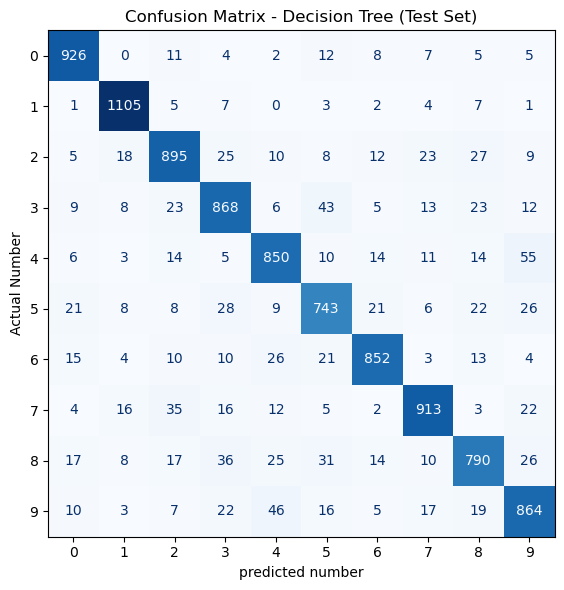

In [23]:
evaluate_model(
    model=dt, 
    model_name="Decision Tree", 
    x_train=X_train, y_train=y_train, 
    x_val=X_val, y_val=y_val, 
    x_test=X_test, y_test=y_test
)

KNN

In [ ]:

param_grid_knn = {
    'n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10],
    'weights': ['uniform', 'distance']
}


knn_base = KNeighborsClassifier()

grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=3,                 
    scoring='accuracy',
    n_jobs=-1             
)



grid_search_knn.fit(X_train, y_train)



print(f"Dein bestes Modell nutzt: {grid_search_knn.best_params_}")
print(f"Durchschnittliche Genauigkeit (Cross-Validation): {grid_search_knn.best_score_ * 100:.2f}%")


optimized_knn = grid_search_knn.best_estimator_

In [17]:
best_paramsknn = {
"n_neighbors" : 4,
"weights" : "distance",
   
}


In [18]:
start_time = time.time()

knn = KNeighborsClassifier(
    **best_paramsknn
    
)


knn.fit(X_train, y_train)

training_time = time.time() - start_time


KNN Train Evaluation
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 score : 1.0000
**********************
KNN Validation Evaluation
Accuracy : 0.9715
Precision: 0.9720
Recall   : 0.9711
F1 score : 0.9714
**********************
KNN Test Evaluation
Accuracy : 0.9716
Precision: 0.9718
Recall   : 0.9713
F1 score : 0.9714


Erstelle Confusion Matrix für KNN (Testdaten)...


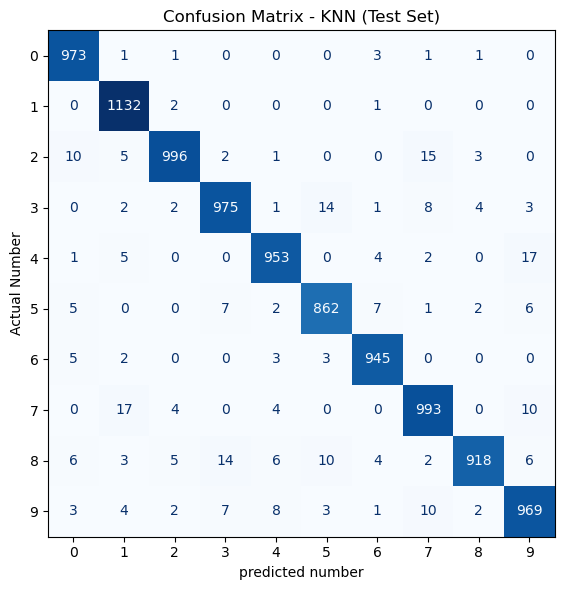

In [22]:
evaluate_model(
    model=knn, 
    model_name="KNN", 
    x_train=X_train, y_train=y_train, 
    x_val=X_val, y_val=y_val, 
    x_test=X_test, y_test=y_test
)

logistic regression

In [ ]:
param_grid_logreg = {
    "C": [0.1, 1.0, 10.0],          
    "penalty": [ "l2"],        
    "solver": ["lbfgs"]              
}


grid_search_logreg = GridSearchCV(
    estimator=LogisticRegression(max_iter=500, random_state=42),
    param_grid=param_grid_logreg,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

print("Starte GridSearch für Logistische Regression...")
grid_search_logreg.fit(X_train, y_train)

print("Die besten Parameter sind:")
print(grid_search_logreg.best_params_)

In [20]:

best_paramsLg= {
    'C': 0.1, 
    'penalty': 'l2', 
    'solver': 'lbfgs'
}


In [24]:

Lg = LogisticRegression(
    **best_paramsLg, 
    max_iter=500, 
    random_state=42
)

Lg.fit(X_train, y_train)

y_val_pred = Lg.predict(X_val)

logisticRegression Train Evaluation
Accuracy : 0.9324
Precision: 0.9316
Recall   : 0.9315
F1 score : 0.9315
**********************
logisticRegression Validation Evaluation
Accuracy : 0.9215
Precision: 0.9209
Recall   : 0.9206
F1 score : 0.9207
**********************
logisticRegression Test Evaluation
Accuracy : 0.9247
Precision: 0.9238
Recall   : 0.9236
F1 score : 0.9236


Erstelle Confusion Matrix für logisticRegression (Testdaten)...


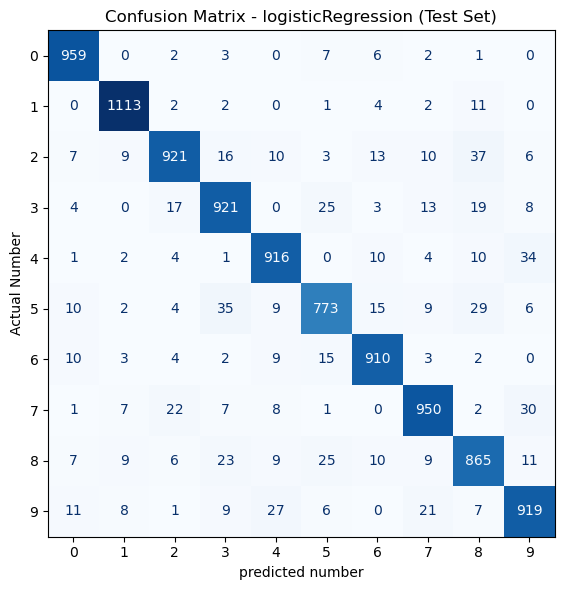

In [25]:
evaluate_model(
    model=Lg, 
    model_name="logisticRegression", 
    x_train=X_train, y_train=y_train, 
    x_val=X_val, y_val=y_val, 
    x_test=X_test, y_test=y_test
)

model comparisonn function

In [33]:
def plot_model_comparison(models_dict, X_test, y_test):
    
    
    # Lists
    metrics_data = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1 Score": []
    }
    
    model_names = list(models_dict.keys())
    
    
    
    for name, model in models_dict.items():
        y_pred = model.predict(X_test)
        
        metrics_data["Accuracy"].append(accuracy_score(y_test, y_pred))
        metrics_data["Precision"].append(precision_score(y_test, y_pred, average='macro'))
        metrics_data["Recall"].append(recall_score(y_test, y_pred, average='macro'))
        metrics_data["F1 Score"].append(f1_score(y_test, y_pred, average='macro'))
        
    # --- Plotting ---
    x = np.arange(len(model_names))  
    width = 0.2  
    multiplier = 0
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    
    for attribute, measurement in metrics_data.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        
        
        ax.bar_label(rects, padding=3, fmt='%.3f', fontsize=9)
        multiplier += 1
        
    
    ax.set_ylabel('Score')
    ax.set_title('Vergleich der Test-Performance: Basis-Modelle vs. Ensemble', fontsize=14, fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.legend(loc='lower right', fontsize=10)
    
    
    ax.set_ylim(0.85, 1.02) 
    
   
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()

ensemble

In [ ]:
#stacking
# I tried some more ensmeble methods but this one had the best results 
estimators = [
    ('decision_tree', dt),
    ('knn', knn),
    ('log_reg', Lg) 
]

#
meta_model = HistGradientBoostingClassifier(max_iter=50, random_state=42)

# 3. Den Stacking Classifier zusammenbauen
stacking_ensemble = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    passthrough=True,
    cv=5,  
    n_jobs=-1 
)


print("Starte Stacking-Training... ")
start_time = time.time()


stacking_ensemble.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"Stacking Training done in {training_time:.2f} Sekunden.")

Starte Stacking-Training... 
Stacking Training abgeschlossen in 91.35 Sekunden.


Stacking Ensemble Train Evaluation
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 score : 1.0000
**********************
Stacking Ensemble Validation Evaluation
Accuracy : 0.9783
Precision: 0.9783
Recall   : 0.9782
F1 score : 0.9782
**********************
Stacking Ensemble Test Evaluation
Accuracy : 0.9782
Precision: 0.9782
Recall   : 0.9780
F1 score : 0.9781


Erstelle Confusion Matrix für Stacking Ensemble (Testdaten)...


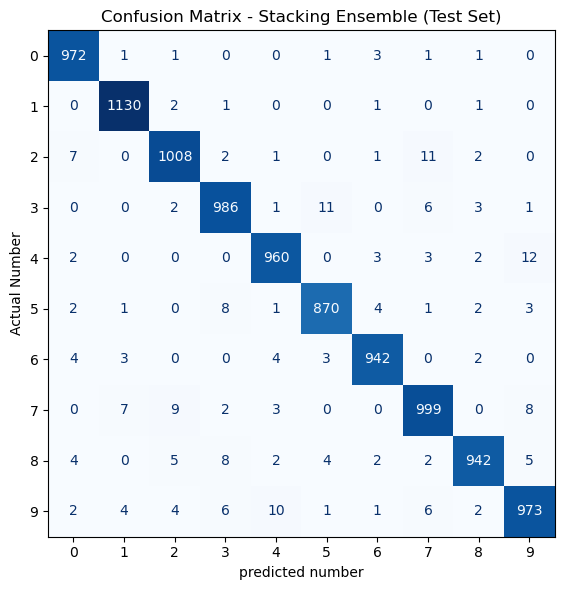

In [28]:
evaluate_model(
    model=stacking_ensemble, 
    model_name="Stacking Ensemble", 
    x_train=X_train, y_train=y_train, 
    x_val=X_val, y_val=y_val, 
    x_test=X_test, y_test=y_test
)

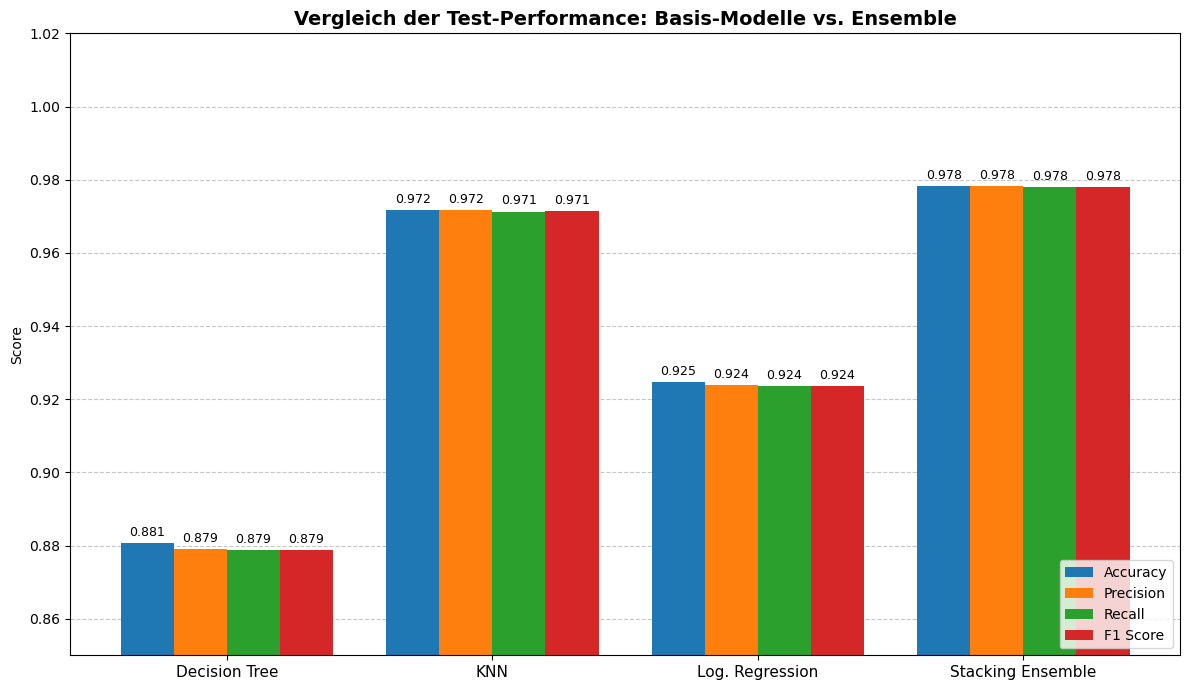

In [34]:
# summary
meine_modelle = {
    "Decision Tree": dt,
    "KNN": knn,
    "Log. Regression": Lg,
    "Stacking Ensemble": stacking_ensemble
}


plot_model_comparison(meine_modelle, X_test, y_test)